In [28]:
! pip install pandas
! pip install -U scikit-learn
! pip install matplotlib

In [29]:
import pandas # to load in our data
from sklearn import tree # to print our decision tree
from sklearn.tree import DecisionTreeClassifier # to train our decision tr

In our example, we want to decide whether or not someone is drunk at your degenerate friend's darty.

We have the following columns:

* FavoriteNumber: [INT]
* HoursAwake: [INT]
* ShotsTaken: [INT]
* Year: [STRING] 
* Drunk: [STRING]

In [38]:
# first import our dataset
df = pandas.read_csv("data.csv")

In [ ]:
# since year is a string, we must make it an integer for the model
# to be able to learn from it. 
d = {'FIRST': 0, 'SECOND': 1, 'THIRD': 2}
df['Year'] = df['Year'].map(d)

# We do the same to our class: whether or not someone is drunk.
d = {'YES': 1, 'NO': 0}
df['Drunk'] = df['Drunk'].map(d)

In [ ]:
# now, we define the features. The non-class columns are our features
# to determine whether or not someone is drunk
features = ['FavoriteNumber', 'HoursAwake', 'ShotsTaken', 'Year']
X = df[features]
y = df['Drunk']

# now, we train the decision tree
dtree = DecisionTreeClassifier()
dtree = dtree.fit(X, y)

[Text(0.6666666666666666, 0.875, 'ShotsTaken <= 6.5\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.5, 0.625, 'ShotsTaken <= 4.5\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'HoursAwake <= 8.0\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.16666666666666666, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8333333333333334, 0.625, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.75, 0.75, '  False')]

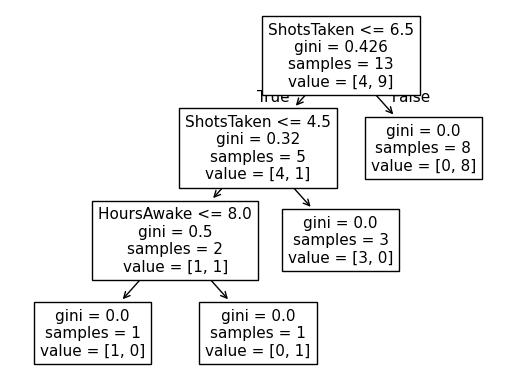

In [ ]:
# let's see our tree
tree.plot_tree(dtree, feature_names=features)

To read this tree, here is the guide:
* We use the gini index to measure which features is best. Remember, a low gini index (close to 0) means a perfectly segregated split. A gini index closer to 0.5 means a perfectly even split--right down the middle.
* Our strongest feature is number of shots taken.
* To figure out whether or not someone is drunk, the boxes with gini = 0.0 on the right mean "yes" and the ones of the left mean "no"

# If someone took more than 6.5 shots, they are drunk. Otherwise, we go down to the next strongest feature: ShotsTaken <= 4.5
* If someone took more than 4.5 shots, they are drunk

# If someone took less than or equal to 4.5 shots, we check how many hours they have been awake for.
* People who have been awake for more than 8 hours are drunk.
* People who have not been awake for more than 8 hours are sober.